In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

import numpy as np
import matplotlib.pyplot as plt

In [4]:
model = tf.keras.models.load_model('/content/drive/MyDrive/brain-tumor-classification/models/best_model.keras') # Paste the path to your saved model here

c:\Users\nmarm\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 140 variables whereas the saved optimizer has 144 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [7]:
IMG_SIZE = (224, 224)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

def predict_image(model, img_path, class_names):
    # Load image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    # Expand dims
    img_array = np.expand_dims(img_array, axis=0)

    # If your model has preprocessing inside → DO NOT preprocess again
    img_array = tf.cast(img_array, tf.float32)

    # Prediction
    preds = model.predict(img_array, verbose=0)
    pred_index = np.argmax(preds[0])
    confidence = float(np.max(preds[0]))

    return img, pred_index, confidence

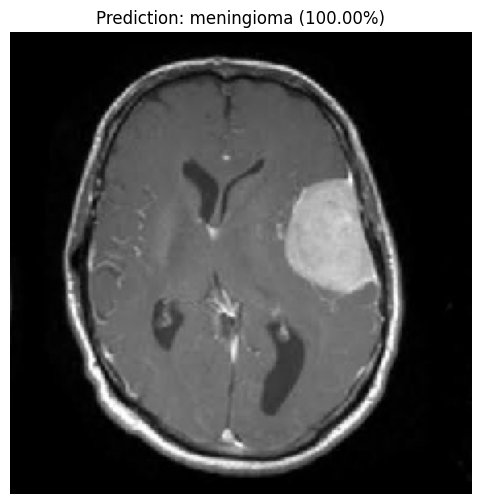

In [ ]:
# Random Testing
img, pred_index, confidence = predict_image(model, "/content/meningioma.png", class_names) # Paste the path to your test image here

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Prediction: {class_names[pred_index]} ({confidence:.2%})")
plt.axis("off")
plt.show()